In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
train = pd.read_csv('../Dataset/train.csv')
test = pd.read_csv('../Dataset/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (614, 13)
Test shape: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
train.info()
print("\nMissing values:\n", train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Missing values:
 Loan_ID               0
Gender               13
Married               3
Dependents           1

In [3]:
# Fill missing values
train['Gender'] = train['Gender'].fillna(train['Gender'].mode()[0])
train['Married'] = train['Married'].fillna(train['Married'].mode()[0])
train['Dependents'] = train['Dependents'].fillna(train['Dependents'].mode()[0])
train['Self_Employed'] = train['Self_Employed'].fillna(train['Self_Employed'].mode()[0])
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])
train['Credit_History'] = train['Credit_History'].fillna(train['Credit_History'].mode()[0])

# LoanAmount has skewed distribution, so use median instead of mean
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())

# Verify no missing values remain
print("Missing values after imputation:\n", train.isnull().sum())

Missing values after imputation:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


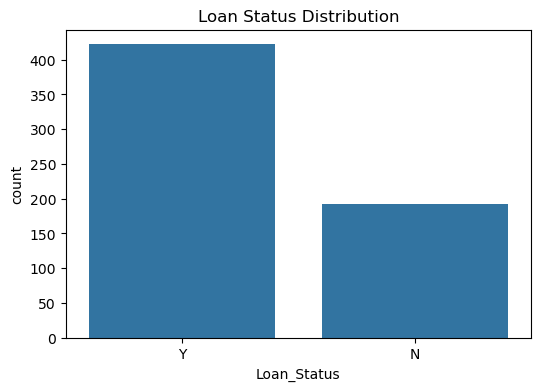

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [4]:
# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=train)
plt.title('Loan Status Distribution')
plt.show()

print(train['Loan_Status'].value_counts(normalize=True) * 100)

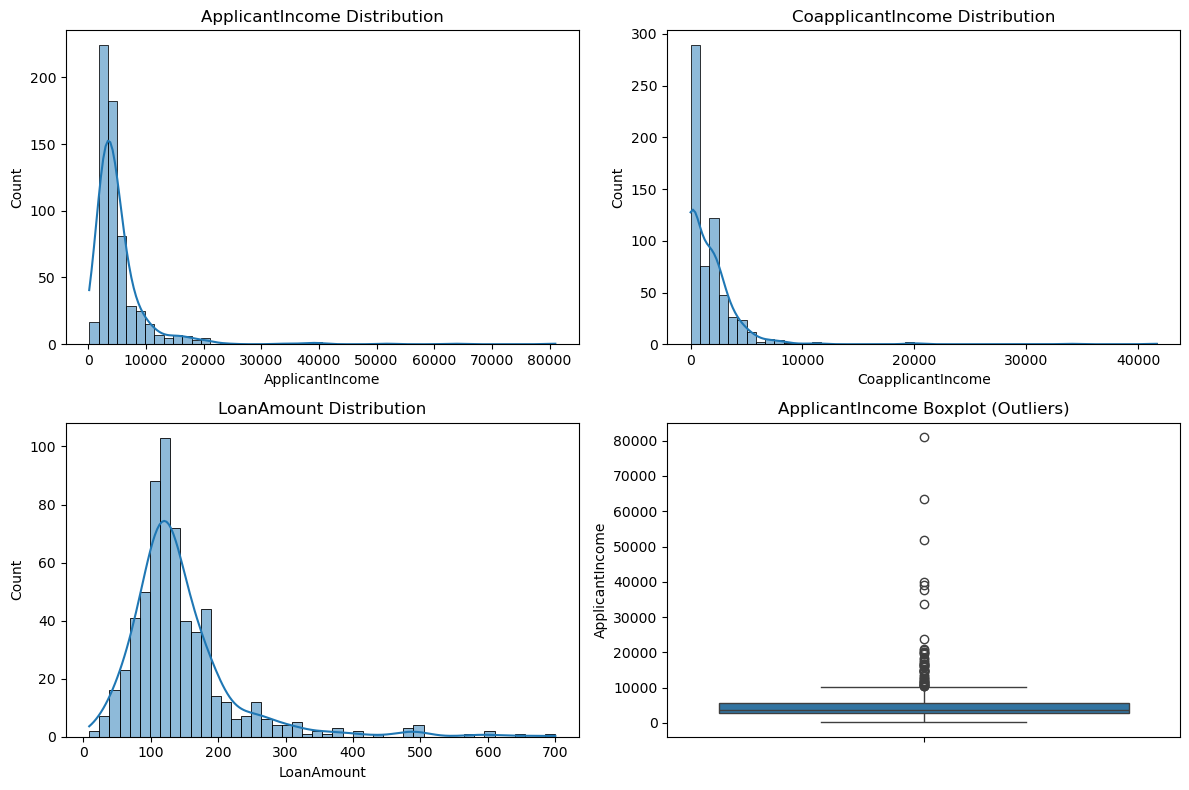

In [5]:
# Univariate Analysis - Numerical features
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(train['ApplicantIncome'], kde=True, ax=axes[0,0])
axes[0,0].set_title('ApplicantIncome Distribution')

sns.histplot(train['CoapplicantIncome'], kde=True, ax=axes[0,1])
axes[0,1].set_title('CoapplicantIncome Distribution')

sns.histplot(train['LoanAmount'], kde=True, ax=axes[1,0])
axes[1,0].set_title('LoanAmount Distribution')

sns.boxplot(y=train['ApplicantIncome'], ax=axes[1,1])
axes[1,1].set_title('ApplicantIncome Boxplot (Outliers)')

plt.tight_layout()
plt.show()

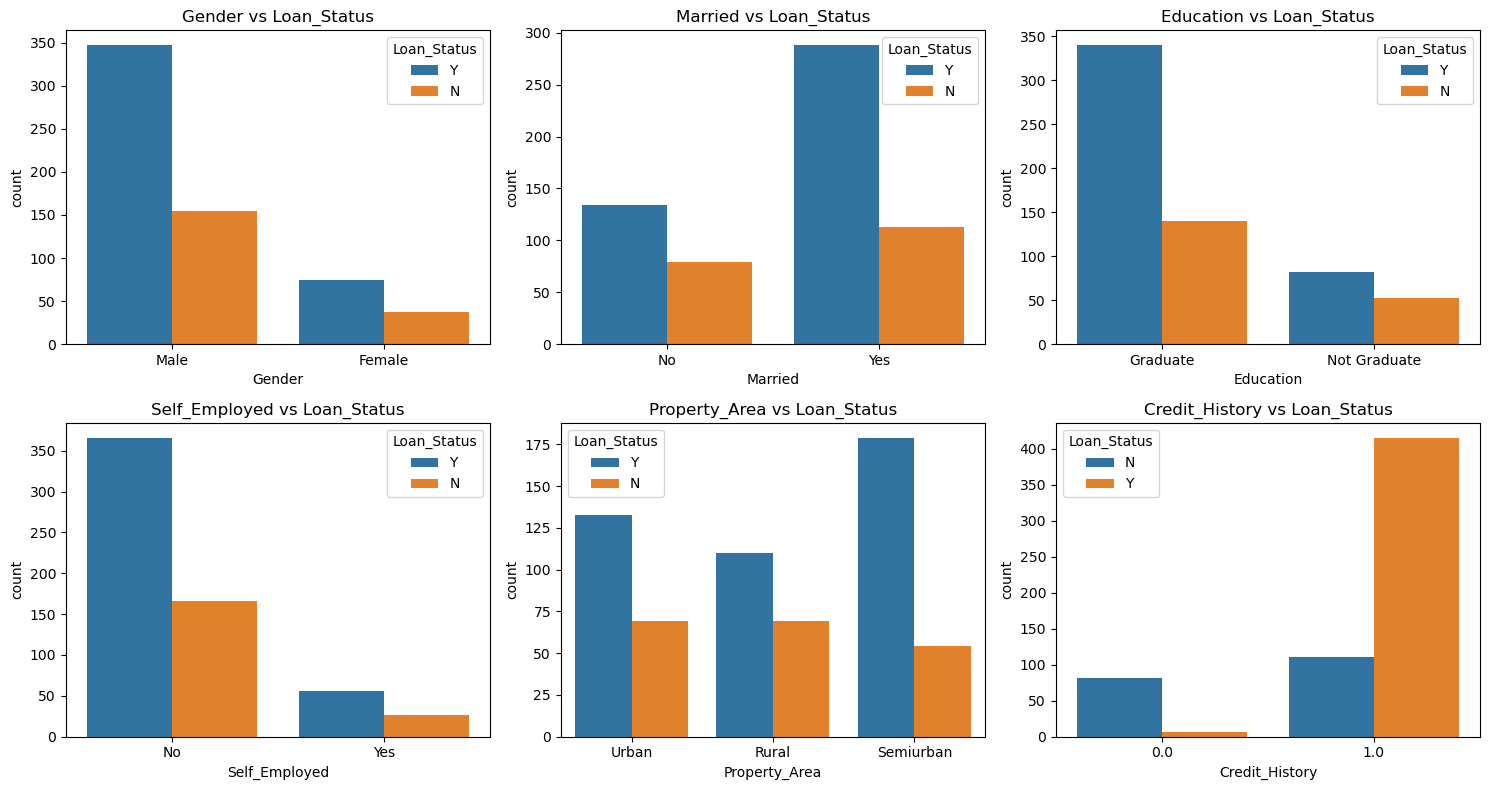

In [6]:
# Bivariate Analysis - Categorical vs Loan_Status
fig, axes = plt.subplots(2, 3, figsize=(15,8))
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Loan_Status', data=train, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'{col} vs Loan_Status')

plt.tight_layout()
plt.show()

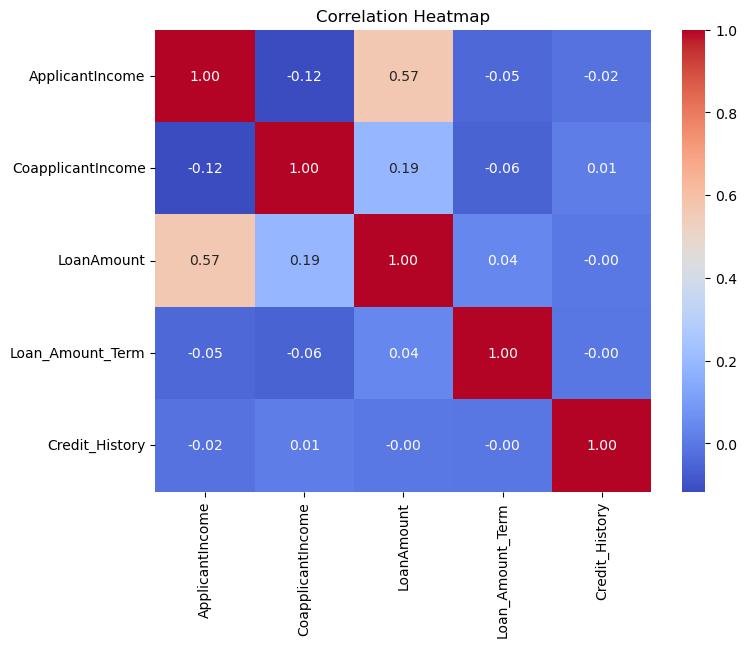

In [7]:
# Correlation Analysis
plt.figure(figsize=(8,6))
numeric_cols = train.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

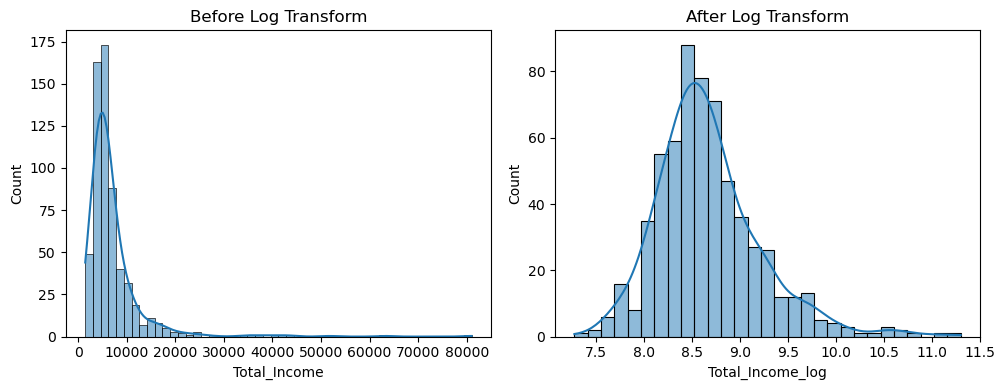

In [8]:
# Feature Engineering - create Total_Income
train['Total_Income'] = train['ApplicantIncome'] + train['CoapplicantIncome']

# Log transform to handle skewness (income and loan amount are right-skewed)
train['Total_Income_log'] = np.log(train['Total_Income'])
train['LoanAmount_log'] = np.log(train['LoanAmount'])

# Visualize the transformation effect
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(train['Total_Income'], kde=True, ax=axes[0])
axes[0].set_title('Before Log Transform')
sns.histplot(train['Total_Income_log'], kde=True, ax=axes[1])
axes[1].set_title('After Log Transform')
plt.tight_layout()
plt.show()

In [9]:
# Drop Loan_ID (not useful for prediction)
train_model = train.drop('Loan_ID', axis=1)

# Encode target variable
train_model['Loan_Status'] = train_model['Loan_Status'].map({'Y': 1, 'N': 0})

# Encode Dependents (3+ needs special handling)
train_model['Dependents'] = train_model['Dependents'].replace('3+', 3).astype(int)

# One-hot encode remaining categorical columns
train_model = pd.get_dummies(train_model, columns=['Gender', 'Married', 'Education', 
                                                       'Self_Employed', 'Property_Area'], 
                               drop_first=True)

print(train_model.shape)
train_model.head()

(614, 16)


,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Total_Income_log,LoanAmount_log,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,1,5849.0,8.674026,4.852030,True,False,False,False,False,True
1,1,4583,1508.0,128.0,360.0,1.0,0,6091.0,8.714568,4.852030,True,True,False,False,False,False
2,0,3000,0.0,66.0,360.0,1.0,1,3000.0,8.006368,4.189655,True,True,False,True,False,True
3,0,2583,2358.0,120.0,360.0,1.0,1,4941.0,8.505323,4.787492,True,True,True,False,False,True
4,0,6000,0.0,141.0,360.0,1.0,1,6000.0,8.699515,4.948760,True,False,False,False,False,True


In [10]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Features and target
X = train_model.drop('Loan_Status', axis=1)
y = train_model['Loan_Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                        random_state=42, stratify=y)

print("Before SMOTE:", y_train.value_counts())

# Handle class imbalance using SMOTE (only on training data)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: Loan_Status
1    337
0    154
Name: count, dtype: int64
After SMOTE: Loan_Status
1    337
0    337
Name: count, dtype: int64


In [14]:
!pip install xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train_sm)

# Model 2: Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_sm, y_train_sm)

# Model 3: XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_sm, y_train_sm)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest': (rf, X_test),
    'XGBoost': (xgb, X_test)
}

results = []

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.829268   0.840426  0.929412  0.882682  0.736842
1        Random Forest  0.845528   0.875000  0.905882  0.890173  0.823994
2              XGBoost  0.813008   0.869048  0.858824  0.863905  0.790402


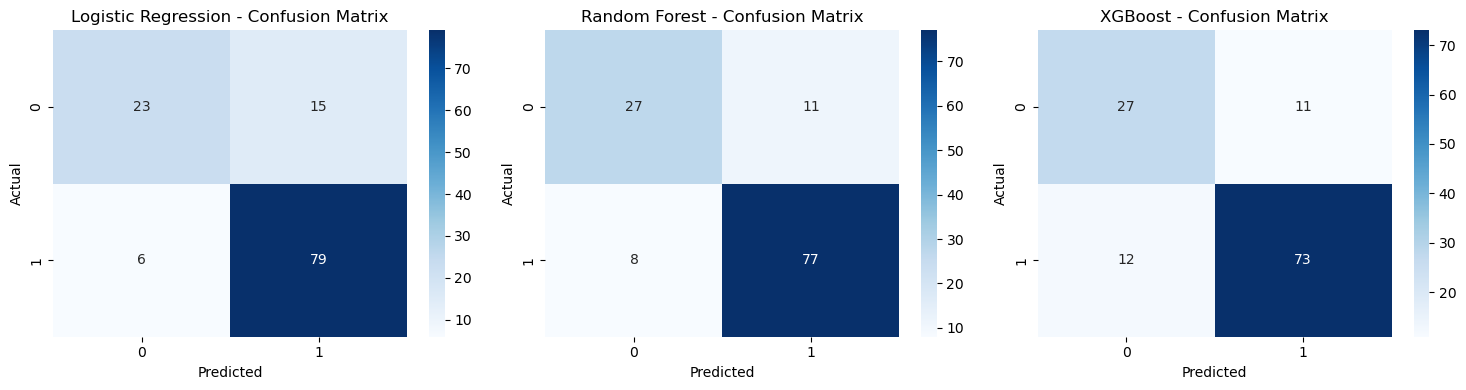

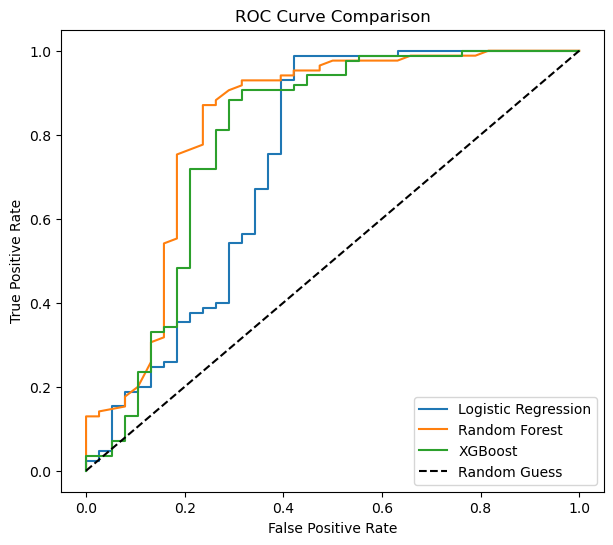

In [16]:
from sklearn.metrics import confusion_matrix, roc_curve

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, (name, (model, X_te)) in enumerate(models.items()):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} - Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(7,6))
for name, (model, X_te) in models.items():
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name}')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [17]:
import joblib

# Save the final model (Random Forest - best performer)
joblib.dump(rf, '../Model/loan_approval_model.pkl')

# Also save the column names (needed for Streamlit input form)
joblib.dump(X.columns.tolist(), '../Model/model_columns.pkl')

print("Model saved successfully!")
print("Columns:", X.columns.tolist())

Model saved successfully!
Columns: ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Total_Income', 'Total_Income_log', 'LoanAmount_log', 'Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']
